# MNIST Classification Project
This notebook demonstrates how to build and evaluate a binary classifier to identify the digit '5' using the MNIST dataset.

In [ ]:
from sklearn.datasets import fetch_openml
import numpy as np
mnist=fetch_openml('mnist_784',as_frame=False)
X,y=mnist["data"],mnist["target"]
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X shape:  (70000, 784)
y shape:  (70000,)


### 1.2 Visualizing a Sample Digit

**What happened:** We took the first image from the dataset (`X[0]`), reshaped its 784 pixel values into a 28x28 grid, and then used `matplotlib.pyplot` to display it as a binary image.

**Why:** Visualizing a sample digit helps us confirm that the data was loaded correctly and that the image representation makes sense. It's a quick visual check to ensure our features correspond to actual handwritten digits.

### 1. Data Loading
**What happened:** We fetched the MNIST dataset (70,000 images of handwritten digits) using `fetch_openml`.
**Why:** We need a standardized dataset to train and test our machine learning model.

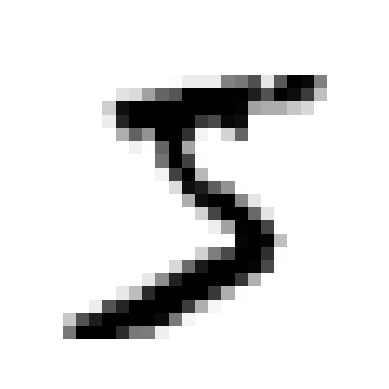

Label:  5


In [ ]:
import matplotlib.pyplot as plt
some_digit=X[0]
some_digit_image=some_digit.reshape(28,28)
plt.imshow(some_digit_image,cmap="binary")
plt.axis("off")
plt.show()
print("Label: ",y[0])

### 1.3 Splitting Data into Training and Test Sets

**What happened:** The dataset was divided into two main parts:
- **Training set (`X_train`, `y_train`):** The first 60,000 images and their labels.
- **Test set (`X_test`, `y_test`):** The remaining 10,000 images and their labels.
We also ensured that all labels (`y`, `y_train`, `y_test`) were explicitly cast to `np.uint8` (unsigned 8-bit integers).

**Why:**
- **Training and Testing:** It is standard practice in machine learning to train a model on one subset of the data and evaluate its performance on a separate, unseen subset. This helps assess how well the model generalizes to new data rather than just memorizing the training examples.
- **Data Type Conversion (`astype(np.uint8)`):** The labels often come as strings or objects. Converting them to integers (specifically `uint8` for digits 0-9) is crucial for most machine learning algorithms that expect numerical input for target variables. It also optimizes memory usage.

### 2. Data Visualization
**What happened:** We reshaped a 1D array of 784 pixels back into a 28x28 image and displayed it.
**Why:** It is important to visualize the data to verify that the features (pixels) correctly represent the digits we are trying to classify.

In [ ]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Convert string to int using the correct type: uint8
y = y.astype(np.uint8)
y_train = y_train.astype(np.uint8)
y_test = y_test.astype(np.uint8)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 60000
Test size: 10000


### 3. Data Splitting
**What happened:** We split the data into a training set (first 60,000) and a test set (last 10,000) and converted labels to integers.
**Why:** We train on one set and test on another to see how well the model generalizes to new, unseen data.

In [ ]:
y_train_5=(y_train==5)
y_train_5=(y_train==5)
print("y_trian_5 sample:",y_train_5[:5])

y_trian_5 sample: [ True False False False False]


### 4. Creating a Binary Target
**What happened:** We created a boolean array where 'True' represents the digit 5 and 'False' represents all other digits.
**Why:** We are starting with a '5-detector', which is a binary classifier, to simplify the classification problem.

In [ ]:
# Train model
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)
print("Model Trained!")

Model Trained!


### 5. Training the Model
**What happened:** We initialized an `SGDClassifier` and fitted it to our training data.
**Why:** Stochastic Gradient Descent (SGD) is efficient for handling large datasets and serves as a strong baseline for linear classification.

In [ ]:
some_digits=X[0]
print("Prediction:",sgd_clf.predict([some_digit]))
print("Actual Label",y_train_5[0])

Prediction: [ True]
Actual Label True


### 6. Making a Prediction
**What happened:** We used the trained model to predict if a specific digit (the first one in the set) is a 5.
**Why:** This allows us to perform a quick sanity check to see if the model's logic is working on individual instances.

### Model Evaluation using Cross-Validation

To get a better measure of our model's performance than a single training set can provide, we use **K-fold Cross-Validation**.

**What happened in the code:**
1. **`cross_val_score(...)`**: This function splits the training set (`X_train`) into K folds (in this case, `cv=3`).
2. **Training & Testing**: It trains the model 3 times, each time using 2 folds for training and the remaining 1 fold for evaluation.
3. **`scoring="accuracy"`**: We are measuring the ratio of correct predictions (both True Positives and True Negatives) to the total number of instances.

**Why we use this:**
- **Robustness**: It ensures the model's performance isn't just a result of a 'lucky' split of data.
- **Generalization**: It gives a more realistic estimate of how the model will perform on unseen data.

In [ ]:
#Accuracy
from sklearn.model_selection import cross_val_score
scores=cross_val_score(sgd_clf,X_train,y_train_5,
                      cv=3,scoring="accuracy")
print("Accuracy Scores:",scores.round(4))
print("Mean Accuracy:",scores.mean().round(4))


Accuracy Scores: [0.9504 0.9604 0.9604]
Mean Accuracy: 0.957


### 7. Cross-Validation Predictions

**What happened:** We used `cross_val_predict` to get clean predictions for each instance in the training set, where the prediction for each instance is made by a model that was trained on a fold that did *not* include that instance.

**Why:** These 'out-of-fold' predictions are crucial for evaluating the model on data it hasn't seen during training, preventing data leakage and providing a more reliable basis for calculating metrics like the confusion matrix.

In [ ]:

# Cross Val Predict
from sklearn.model_selection import cross_val_predict
y_train_pred=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)
print("Prediction ready!")

Prediction ready!


### 8. Confusion Matrix Calculation

**What happened:** We calculated the confusion matrix using `sklearn.metrics.confusion_matrix` with the true labels (`y_train_5`) and the cross-validated predictions (`y_train_pred`).

**Why:** The confusion matrix provides a detailed breakdown of correct and incorrect classifications, showing True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN). It's a fundamental tool for understanding the types of errors a classifier makes.

In [ ]:
import sklearn.metrics
cm = sklearn.metrics.confusion_matrix(y_train_5, y_train_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[53892   687]
 [ 1891  3530]]


### 9. Confusion Matrix Visualization

**What happened:** We visualized the calculated confusion matrix as a heatmap using `matplotlib.pyplot`.

**Why:** A visual representation of the confusion matrix makes it much easier to interpret the model's performance at a glance, highlighting where the model is performing well and where it is struggling (e.g., distinguishing '5's from 'not 5's).

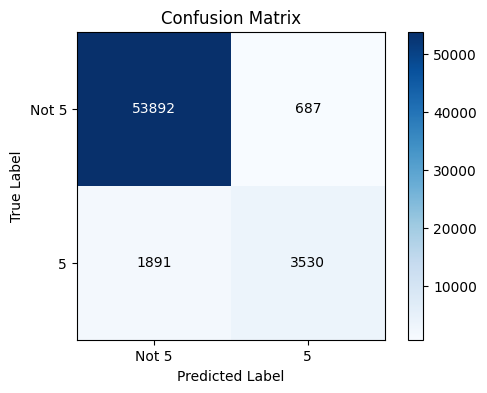

In [ ]:
# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.imshow(cm,cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks([0,1],["Not 5","5"])
plt.yticks([0,1],["Not 5","5"])
for i in range(2):
  for j in range(2):
    plt.text(j,i,cm[i,j],
             ha="center",va="center",
             color="white" if cm[i,j] > 20000 else "black")
plt.show()

### 10. Performance Metrics: Precision, Recall, and F1 Score

**What happened:** We calculated Precision, Recall, and the F1 Score using `sklearn.metrics` functions.

**Why:** These metrics are more informative than accuracy for binary classifiers, especially when dealing with imbalanced datasets (like our '5-detector' where 'not 5's are more common).
- **Precision** measures the accuracy of positive predictions (of all the times it predicted '5', how many were actually '5's?).
- **Recall** measures the ability of the classifier to find all the positive samples (of all the actual '5's, how many did it correctly identify?).
- **F1 Score** is the harmonic mean of precision and recall, providing a single metric that balances both.

In [ ]:
# Precision aur Recall
from sklearn.metrics import precision_score,recall_score,f1_score
precision=precision_score(y_train_5,y_train_pred)
recall=recall_score(y_train_5,y_train_pred)
f1=f1_score(y_train_5,y_train_pred)
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')

Precision: 0.837
Recall: 0.651
F1 Score: 0.733


### 11. Classification Report

**What happened:** We generated a comprehensive `classification_report` from `sklearn.metrics`.

**Why:** This report provides a detailed summary of precision, recall, f1-score, and support for each class ('not 5' and '5'). It's a quick way to get an overview of the classifier's performance across all relevant metrics.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_train_5,y_train_pred,
                            target_names=["Not 5","5"]))

              precision    recall  f1-score   support

       Not 5       0.97      0.99      0.98     54579
           5       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



### 12. Decision Scores

**What happened:** We obtained the decision scores for each instance in the training set using `cross_val_predict` with `method="decision_function"`.

**Why:** Decision scores represent the confidence level of the classifier for each prediction. They are crucial for tasks like plotting the Precision-Recall curve, where we want to analyze the trade-off between precision and recall at various classification thresholds.

In [ ]:
# Decision scores nikalo
y_score=cross_val_predict(sgd_clf,X_train,y_train_5,
                          cv=3,
                          method="decision_function")
print("Score sample:", y_score[:5].round(2))

Score sample: [  1200.93 -26883.79 -33072.03 -15919.55 -20003.54]


### 13. Generating Precision-Recall Curve Data

**What happened:** We used `precision_recall_curve` from `sklearn.metrics` to calculate precision, recall, and corresponding thresholds from the true labels (`y_train_5`) and the decision scores (`y_score`).

**Why:** These arrays are the raw data required to plot the Precision-Recall curve, which visually represents how precision and recall change as the decision threshold varies. This helps in selecting an optimal threshold.

In [ ]:
# Precision Recall Curve
from sklearn.metrics import precision_recall_curve
precisions,recalls,thresholds=precision_recall_curve(y_train_5,y_score)
print("Thresholds:",len(thresholds))

Thresholds: 60000


### 14. Visualizing Precision-Recall Curve and Threshold Relationship

**What happened:** We generated two plots:
1. **Precision & Recall vs Threshold:** Shows how precision and recall values change across different decision thresholds.
2. **Precision vs Recall Curve (PR Curve):** Plots precision directly against recall.

**Why:** The Precision-Recall curve is particularly useful for evaluating binary classifiers on imbalanced datasets. It helps visualize the trade-off between precision and recall and assists in choosing a threshold that balances these two metrics according to the specific needs of the application. The Precision & Recall vs Threshold plot gives insight into which threshold value achieves a desired balance.

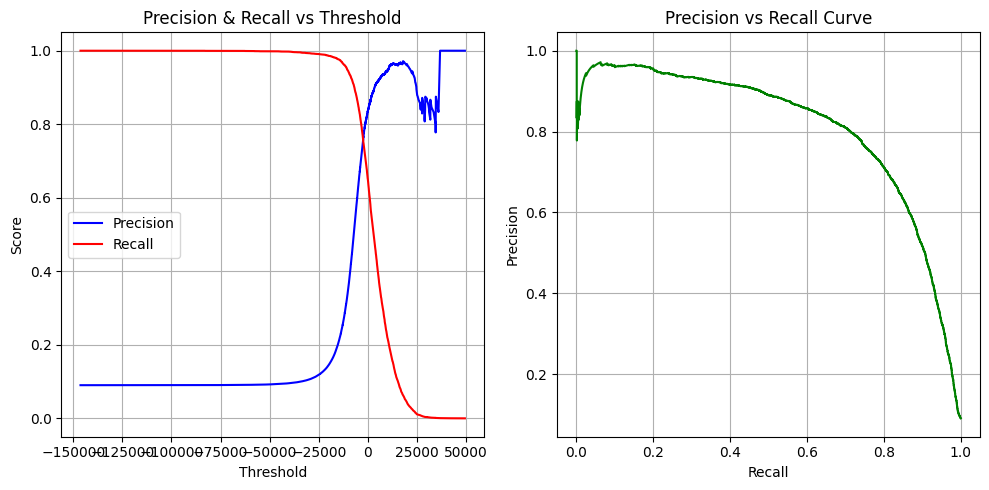

In [ ]:
# Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Precision & Recall vs Threshold
plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], "b-", label="Precision")
plt.plot(thresholds, recalls[:-1], "r-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid(True)

# Precision vs Recall
plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, "g-")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Curve")
plt.grid(True)

plt.tight_layout()
plt.savefig("precision_recall.png", dpi=150)
plt.show()

### 15. Finding the Best Threshold

**What happened:** We calculated the F1 score for all possible thresholds and identified the threshold that maximizes this score.

**Why:** Maximizing the F1 score helps find an optimal balance between precision and recall. This 'best threshold' can then be used to make final predictions, aiming for a robust model performance that considers both false positives and false negatives.

In [ ]:
# Best Threshold dhundho — F1 Score maximize karo
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1])
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1 Score:  {f1_scores.max():.3f}")

Best Threshold: -1991.74
Best F1 Score:  0.759


### 16. Calculating ROC Curve Data

**What happened:** We calculated the False Positive Rate (FPR), True Positive Rate (TPR), and corresponding thresholds using `roc_curve` from `sklearn.metrics`. This is done using the true labels (`y_train_5`) and the decision scores (`y_score`).

**Why:** These values are the raw data needed to plot the Receiver Operating Characteristic (ROC) curve, which is a common graphical plot used to illustrate the diagnostic ability of a binary classifier system as its discrimination threshold is varied.

## Next Steps:

Now that we've maximized the F1-Score and plotted the Precision-Recall curve, we can continue to refine our model or explore further analysis based on these results.

In [ ]:
# ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds=roc_curve(y_train_5, y_score)
print("ROC ready!")

ROC ready!


### 17. Visualizing the ROC Curve

**What happened:** We plotted the calculated ROC curve using `matplotlib.pyplot`.

**Why:** The ROC curve visualizes the trade-off between the True Positive Rate (Sensitivity) and False Positive Rate (1 - Specificity) at various classification thresholds. It helps in understanding the classifier's performance across all possible classification thresholds. A curve closer to the top-left corner (higher TPR, lower FPR) indicates better performance, while a diagonal line represents a random classifier.

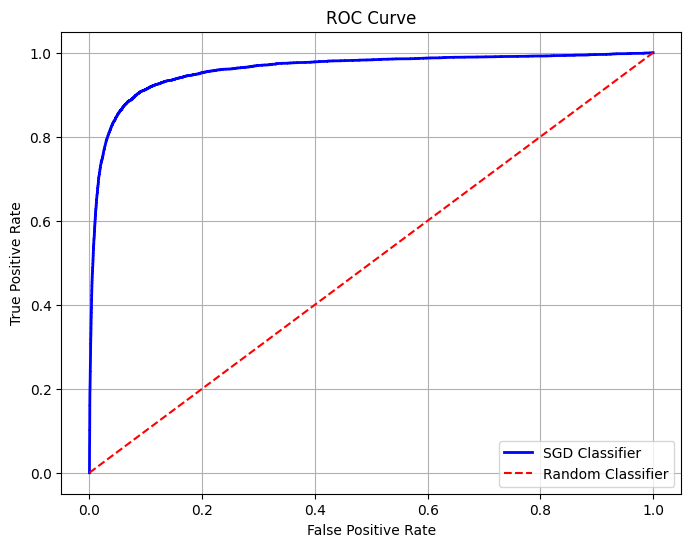

In [ ]:
#- Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b-", linewidth=2, label="SGD Classifier")
plt.plot([0, 1], [0, 1], "r--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

### 18. Calculating the Area Under the ROC Curve (AUC)

**What happened:** We calculated the Area Under the Curve (AUC) for the ROC curve using `roc_auc_score` from `sklearn.metrics`.

**Why:** AUC provides a single scalar value that summarizes the overall performance of a binary classifier across all possible classification thresholds. An AUC of 1.0 indicates a perfect classifier, while an AUC of 0.5 indicates a classifier no better than random guessing. It's particularly useful for comparing different models.

In [ ]:
#- AUC Score
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_train_5, y_score)
print(f"AUC Score: {auc:.3f}")

AUC Score: 0.960


## Multiclass Classification

### 19. Training a Multiclass Classifier

**What happened:** We initialized and trained an `SGDClassifier` using the entire `X_train` dataset and the full multiclass labels `y_train` (digits 0-9).

**Why:** To extend our classification problem from binary (is it a 5 or not?) to multiclass (what digit is it?). The `SGDClassifier` inherently supports multiclass classification using a one-versus-all (OvA) strategy, where it trains one binary classifier for each class.

In [ ]:
# - Multiclass Train
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
print("Multiclass Model Trained!")

Multiclass Model Trained!


### 20. Making a Multiclass Prediction

**What happened:** We used the trained multiclass `SGDClassifier` to predict the digit for the first image in our dataset (`some_digit`).

**Why:** This serves as a quick sanity check to see how the multiclass model assigns a label to a single, known instance. It allows us to compare the model's prediction with the actual label.

In [ ]:
# Prediction
some_digit= X[0]
prediction=sgd_clf.predict([some_digit])
print(f"Predicted:{prediction[0]}")
print(f"Actual:{y_train[0]}")

Predicted:3
Actual:5


### 21. Examining Multiclass Decision Scores

**What happened:** We obtained the decision scores for the `some_digit` from the multiclass classifier using `decision_function`.

**Why:** In a multiclass setting, `decision_function` returns a score for each class. The class corresponding to the highest score is the one the model predicts. These scores indicate the model's confidence for each class, which can be useful for further analysis or threshold adjustments.

In [ ]:
# See decision scores
some_digit_scores=sgd_clf.decision_function([some_digit])
print("Scores:",some_digit_scores.round(2))
print("Highest Scores Index:",some_digit_scores.argmax())
print("Classes",sgd_clf.classes_)

Scores: [[-31893.03 -34419.69  -9530.64   1823.73 -22320.15  -1385.8  -26188.91
  -16147.51  -4604.35 -12050.77]]
Highest Scores Index: 3
Classes [0 1 2 3 4 5 6 7 8 9]


### 22. Cross-Validation Accuracy for Multiclass Model

**What happened:** We calculated the cross-validation accuracy for the multiclass `SGDClassifier` using `cross_val_score` with `cv=3`.

**Why:** Cross-validation provides a more reliable estimate of the model's generalization performance (accuracy) compared to a single train-test split. It helps assess how well the multiclass model performs on unseen data across different subsets of the training data.

In [ ]:
#- Cross Val Accuracy
from sklearn.model_selection import cross_val_score

scores = cross_val_score(sgd_clf, X_train, y_train,
                         cv=3, scoring="accuracy")
print(f"Accuracy: {scores.mean():.4f}")

Accuracy: 0.8670


### 23. Improving Multiclass Performance with Feature Scaling

**What happened:** We applied `StandardScaler` to the training data (`X_train`) to scale its features, and then re-calculated the cross-validation accuracy using the scaled data.

**Why:** Many machine learning algorithms, including `SGDClassifier`, are sensitive to the scale of input features. Scaling features to have zero mean and unit variance (`StandardScaler`) can significantly improve model convergence and overall performance, leading to better accuracy.

In [ ]:
#  - Scaling se Better Results
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

scores_scaled = cross_val_score(sgd_clf, X_train_scaled, y_train,
                                cv=3, scoring="accuracy")
print(f"Scaled Accuracy: {scores_scaled.mean():.4f}")

Scaled Accuracy: 0.8970


### 24. Importing Libraries for Multiclass Evaluation

**What happened:** We imported additional necessary libraries: `cross_val_predict`, `confusion_matrix`, `StandardScaler`, `matplotlib.pyplot`, and `numpy`.

**Why:** These imports ensure that all required functions and classes are available for the subsequent steps, which involve generating cross-validated predictions, calculating and visualizing a multiclass confusion matrix, and performing data scaling.

In [ ]:
#  - Imports
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

print("Imports done!")

Imports done!


### 25. Scaling Training Data for Multiclass Evaluation

**What happened:** We initialized `StandardScaler` and applied its `fit_transform` method to the training data (`X_train`), converting `X_train` to a float64 type before scaling.

**Why:** This step explicitly performs feature scaling on the training dataset. Scaling is crucial for algorithms like SGD to ensure fair weighting of features and to prevent features with larger numerical ranges from dominating the learning process. The `float64` conversion ensures numerical stability during scaling.

In [ ]:
# - Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
print("Scaling done!")

Scaling done!


### 26. Generating Cross-Validated Predictions for Multiclass

**What happened:** We generated cross-validated predictions (`y_train_pred`) for the *scaled* training data using the multiclass `SGDClassifier` and `cross_val_predict`.

**Why:** Similar to binary classification, using `cross_val_predict` ensures that each prediction is made by a model that has not seen that particular instance during its training phase. This provides a robust and unbiased set of predictions essential for accurately computing the multiclass confusion matrix.

In [ ]:
# - Predictions
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
print("Predictions ready!")

Predictions ready!


### 27. Calculating the Multiclass Confusion Matrix

**What happened:** We calculated the confusion matrix using `sklearn.metrics.confusion_matrix` with the true multiclass labels (`y_train`) and the cross-validated predictions (`y_train_pred`).

**Why:** The multiclass confusion matrix provides a detailed breakdown of correct and incorrect classifications for each digit (0-9). Each cell `(i, j)` indicates the number of times an instance of true class `i` was predicted as class `j`. It's invaluable for identifying specific patterns of misclassification.

In [ ]:
# - Confusion Matrix
cm = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5577    0   22    5    8   43   36    6  225    1]
 [   0 6400   37   24    4   44    4    7  212   10]
 [  27   27 5220   92   73   27   67   36  378   11]
 [  22   17  117 5227    2  203   27   40  403   73]
 [  12   14   41    9 5182   12   34   27  347  164]
 [  27   15   30  168   53 4444   75   14  535   60]
 [  30   15   42    3   44   97 5552    3  131    1]
 [  21   10   51   30   49   12    3 5684  195  210]
 [  17   63   48   86    3  126   25   10 5429   44]
 [  25   18   30   64  118   36    1  179  371 5107]]


### 28. Visualizing the Multiclass Confusion Matrix

**What happened:** We visualized the calculated multiclass confusion matrix as a heatmap using `matplotlib.pyplot`.

**Why:** A visual representation of the confusion matrix makes it much easier to interpret the model's performance across all classes. Darker cells along the diagonal indicate correctly classified instances, while darker off-diagonal cells highlight where the model is making errors and confusing certain digits with others.

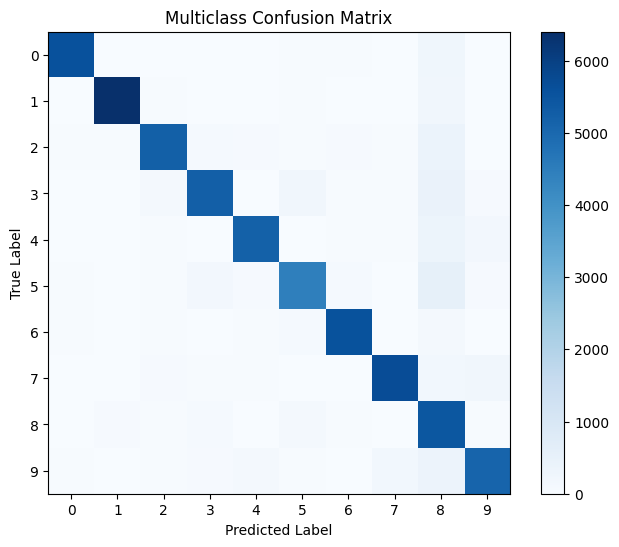

In [ ]:
# - Confusion Matrix Visualize
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Multiclass Confusion Matrix")
plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

### 29. Visualizing the Error Rate Matrix

**What happened:** We created an "Error Rate Matrix" by normalizing the confusion matrix (dividing each value by its row sum) and setting the diagonal elements to zero.

**Why:** This visualization specifically highlights the *proportions* of misclassifications, making it easier to see which digits are most frequently confused with others. By setting the diagonal to zero, we focus exclusively on the errors, allowing for quicker identification of problematic digit pairs (e.g., a 3 being mistaken for a 5, or vice-versa).

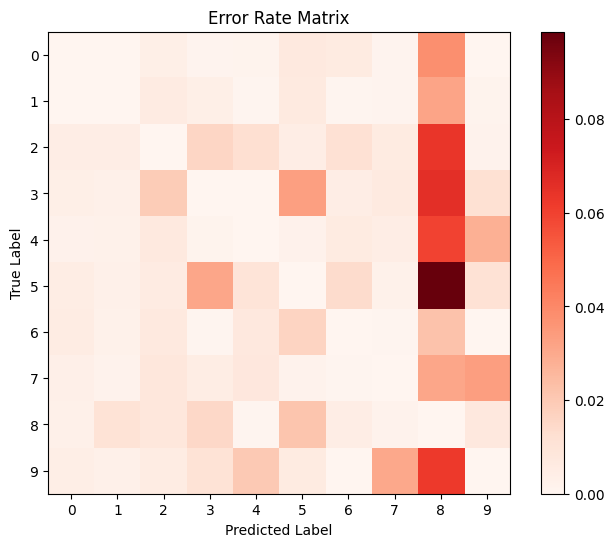

In [ ]:
# - Error Rate Matrix
row_sums = cm.sum(axis=1, keepdims=True)
norm_cm = cm / row_sums
np.fill_diagonal(norm_cm, 0)

plt.figure(figsize=(8, 6))
plt.imshow(norm_cm, cmap="Reds")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Error Rate Matrix")
plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

### 30. Helper Function for Plotting Digits

**What happened:** We defined a Python function `plot_digits` that takes a list of image instances (flattened arrays) and displays them as a grid of 28x28 pixel images.

**Why:** This is a reusable utility function that simplifies the process of visualizing multiple handwritten digits. It's particularly useful for inspecting misclassified examples or comparing original versus reconstructed images, making it easier to visually interpret model behavior.

In [ ]:
# - 3 & 5 wrong Images
def plot_digits(instances, images_per_row=10):
    size = 28 # Assuming 28x28 images

    if len(instances) == 0:
        print("No instances to plot.")
        return

    # Create 2D images from 1D instances
    images_2d = [instance.reshape(size, size) for instance in instances]
    n_instances = len(images_2d)

    n_rows = (n_instances - 1) // images_per_row + 1

    final_image_rows = [] # Will store each row, already horizontally concatenated

    for row_idx in range(n_rows):
        current_row_start_idx = row_idx * images_per_row
        current_row_end_idx = min((row_idx + 1) * images_per_row, n_instances)

        # Extract images for the current row
        current_images_for_row = images_2d[current_row_start_idx:current_row_end_idx]

        # Create a blank canvas for the current row (width = images_per_row * size)
        row_canvas_width = images_per_row * size
        # Use the dtype of the first image for consistency, or uint8 if no images are present
        dtype = images_2d[0].dtype if images_2d else np.uint8
        row_canvas = np.zeros((size, row_canvas_width), dtype=dtype)

        # Place each image onto the canvas
        for col_idx, img in enumerate(current_images_for_row):
            start_col = col_idx * size
            end_col = (col_idx + 1) * size
            row_canvas[:, start_col:end_col] = img

        final_image_rows.append(row_canvas)

    # Concatenate all row canvases vertically
    if not final_image_rows: # If no rows were generated (e.g., n_instances was 0 after filtering)
        print("No image to display.")
        return

    image = np.concatenate(final_image_rows, axis=0)

    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()

### 31. Visualizing Specific Misclassifications (3s vs 5s)

**What happened:** We selected and plotted examples of digits that were correctly classified as 3 or 5, and critically, examples that were *misclassified* (actual 3s predicted as 5s, and actual 5s predicted as 3s).

**Why:** This visual inspection helps us understand *why* the model makes certain errors. By examining the actual images that are confused, we can gain insights into the visual similarities or ambiguities that lead to these specific misclassifications, which can inform future model improvements.

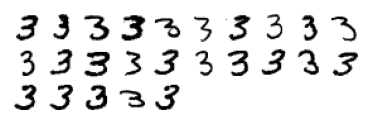

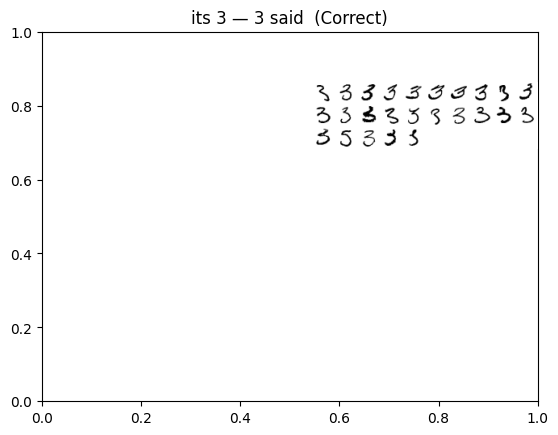

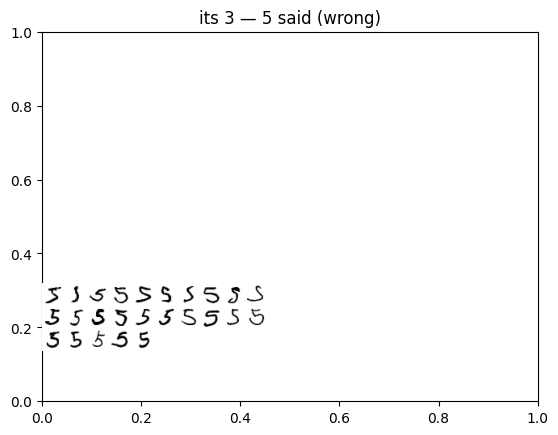

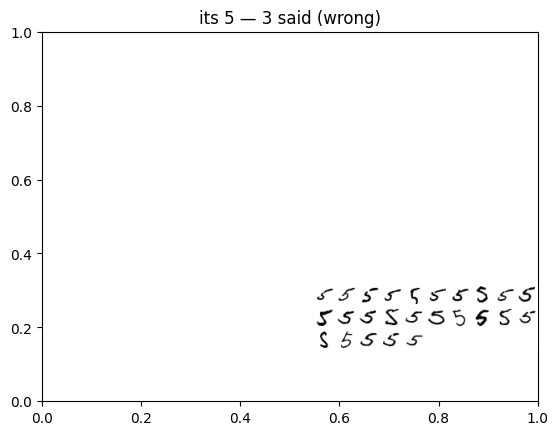

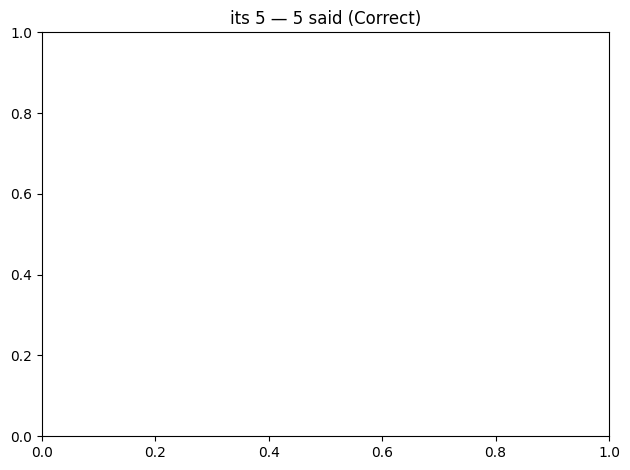

In [ ]:
#  - 3 vs 5 Plot
cl_a, cl_b = 3, 5

X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

plt.figure(figsize=(10, 8))

plt.subplot(221); plot_digits(X_aa[:25])
plt.title("its 3 — 3 said  (Correct)")

plt.subplot(222); plot_digits(X_ab[:25])
plt.title("its 3 — 5 said (wrong)")

plt.subplot(223); plot_digits(X_ba[:25])
plt.title("its 5 — 3 said (wrong)")

plt.subplot(224); plot_digits(X_bb[:25])
plt.title("its 5 — 5 said (Correct)")

plt.tight_layout()
plt.show()

## Multilabel Classification

### 32. Creating a Multilabel Target

**What happened:** We created a new target variable `y_multilabel` where each instance has two labels: one indicating if the digit is 'large' (7, 8, or 9) and another indicating if the digit is 'odd'.

**Why:** This demonstrates a multilabel classification scenario, where a single instance can belong to multiple classes simultaneously. This is a common pattern in many real-world problems (e.g., image tagging where an image might contain multiple objects).

In [ ]:
#  - Multilabel Target
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.column_stack([y_train_large, y_train_odd])
print("Multilabel shape:", y_multilabel.shape)
print("Sample:", y_multilabel[:3])

Multilabel shape: (60000, 2)
Sample: [[False  True]
 [False False]
 [False False]]


### 33. Training a Multilabel Classifier (K-Nearest Neighbors)

**What happened:** We initialized and trained a `KNeighborsClassifier` using the original training data `X_train` and the newly created `y_multilabel` target.

**Why:** The `KNeighborsClassifier` is suitable for multilabel classification, as it can predict multiple output labels for a given input instance. It learns patterns to simultaneously classify whether a digit is large AND whether it is odd.

In [ ]:
# - KNN Train
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)
print("Trained!")

Trained!


### 34. Multilabel Prediction Example

**What happened:** We used the trained `KNeighborsClassifier` to make a multilabel prediction for `some_digit` (which is the digit '5').

**Why:** This shows how the multilabel classifier simultaneously predicts both aspects of the `y_multilabel` target for a single digit, indicating whether '5' is considered large and whether it is odd according to the model's learning.

In [ ]:
# - Prediction
some_digit = X[0]  # 5 hai
pred = knn_clf.predict([some_digit])
print(f"Digit 5 ke liye:")
print(f"Bada hai (>=7)? {pred[0][0]}")
print(f"Odd hai?        {pred[0][1]}")

Digit 5 ke liye:
Bada hai (>=7)? False
Odd hai?        True


## Multioutput Classification / Denoising

### 35. Generating Noisy Images

**What happened:** We created noisy versions of the `X_train` and `X_test` datasets by adding random integer noise (between 0 and 100) to each pixel.

**Why:** This simulates real-world scenarios where images might be corrupted or suffer from noise. It prepares the data for training a denoising model, which aims to reconstruct the original clean image from a noisy input.

In [ ]:
# - Noisy Image
import numpy as np

noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_noisy = X_train + noise
noise_test = np.random.randint(0, 100, (len(X_test), 784))
X_test_noisy = X_test + noise_test
print("Noisy data ready!")

Noisy data ready!


### 36. Training a Multioutput Classifier for Denoising

**What happened:** We initialized and trained a `KNeighborsClassifier` where the input features are the `X_train_noisy` images, and the target labels are the original, clean `X_train` images.

**Why:** This sets up a multioutput classification (or regression) task where the model learns to map a noisy image to its corresponding clean version. The KNN classifier, in this context, acts as a simple denoising agent by finding the 'k' nearest noisy neighbors and averaging their clean counterparts (or taking the mode).

In [ ]:
#  - Multioutput Train
knn_clf2 = KNeighborsClassifier()
knn_clf2.fit(X_train_noisy, X_train)
print("Multioutput Trained!")

Multioutput Trained!


### 37. Visualizing Noisy vs. Cleaned Images

**What happened:** We took a noisy image from the test set (`X_test_noisy`), used the trained multioutput `knn_clf2` to predict its cleaned version, and then displayed both the noisy and cleaned images side-by-side.

**Why:** This visualization provides a direct and intuitive demonstration of the denoising model's effectiveness. By comparing the noisy input with the model's cleaned output, we can visually assess how well the model is able to remove the introduced noise and reconstruct the original digit.

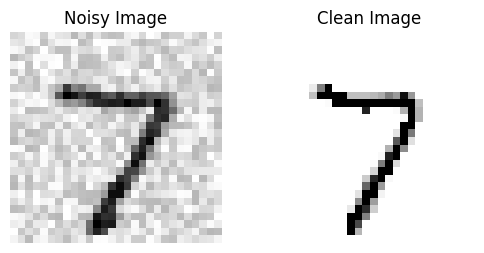

In [ ]:
# - Clean vs Noisy Compare
import matplotlib.pyplot as plt

some_digit_noisy = X_test_noisy[0]
clean_digit = knn_clf2.predict([some_digit_noisy])

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(some_digit_noisy.reshape(28, 28), cmap="binary")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_digit.reshape(28, 28), cmap="binary")
plt.title("Clean Image")
plt.axis("off")

plt.show()